In [4]:
import pandas as pd

df = pd.read_excel("/content/online_retail_II.xlsx")

In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.shape

(525461, 8)

In [6]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [7]:
df_clean = df.copy()

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 525461
Columns: 8


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6865


In [10]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Rows after removing duplicates: 518596


In [11]:
df_clean = df_clean.dropna(subset=["Customer ID"])

print("Rows after removing missing Customer ID:", len(df_clean))

Rows after removing missing Customer ID: 410763


In [12]:
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)

In [13]:
print("Negative Quantity:", (df_clean["Quantity"] < 0).sum())
print("Zero Quantity:", (df_clean["Quantity"] == 0).sum())
print("Negative Price:", (df_clean["Price"] < 0).sum())
print("Zero Price:", (df_clean["Price"] == 0).sum())

Negative Quantity: 9816
Zero Quantity: 0
Negative Price: 0
Zero Price: 31


In [14]:
print("Cancelled invoices:", df_clean["Invoice"].astype(str).str.startswith("C").sum())

Cancelled invoices: 9816


In [15]:
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

In [16]:
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
]

In [17]:
print("Final rows:", len(df_clean))
print("Final columns:", len(df_clean.columns))

df_clean.head()

Final rows: 400916
Final columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [18]:
df_clean.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [19]:
df_clean["Total_Amount"] = df_clean["Quantity"] * df_clean["Price"]

In [20]:
df_clean[["Quantity", "Price", "Total_Amount"]].head()

,Quantity,Price,Total_Amount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [21]:
print(df_clean["InvoiceDate"].dtype)

datetime64[ns]


In [22]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [23]:
print(df_clean["InvoiceDate"].min())
print(df_clean["InvoiceDate"].max())

2009-12-01 07:45:00
2010-12-09 20:01:00


In [24]:
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2010-12-10 20:01:00


In [26]:
rfm = df_clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Total_Amount", "sum")
).reset_index()

In [27]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [28]:
rfm.shape

(4312, 4)

In [29]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


In [30]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [31]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [32]:
rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512
5,12352,11,2,343.80,5,2,2,522
6,12353,44,1,317.76,3,1,2,312
7,12355,203,1,488.21,1,1,2,112
8,12356,16,3,3560.30,4,3,5,435
9,12357,24,2,12079.99,4,2,5,425


In [33]:
print("R Score:")
print(rfm["R_Score"].value_counts().sort_index())

print("\nF Score:")
print(rfm["F_Score"].value_counts().sort_index())

print("\nM Score:")
print(rfm["M_Score"].value_counts().sort_index())

R Score:
R_Score
1    855
2    848
3    850
4    853
5    906
Name: count, dtype: int64

F Score:
F_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64

M Score:
M_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64


In [34]:
rfm.to_csv("RFM_Table.csv", index=False)

print("RFM_Table.csv created successfully.")

RFM_Table.csv created successfully.


In [35]:
def assign_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2 and m >= 3:
        return "Need Attention"

    else:
        return "Lost Customers"

In [36]:
rfm["Segment"] = rfm.apply(assign_segment, axis=1)

In [37]:
rfm[["Customer ID", "RFM_Score", "Segment"]].head(20)

,Customer ID,RFM_Score,Segment
0,12346,252,Lost Customers
1,12347,524,Potential Loyalists
2,12348,211,Lost Customers
3,12349,335,Loyal Customers
4,12351,512,Potential Loyalists
5,12352,522,Potential Loyalists
6,12353,312,Lost Customers
7,12355,112,Lost Customers
8,12356,435,Loyal Customers
9,12357,425,Potential Loyalists


In [38]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Average_Revenue=("Monetary", "mean")
    )
    .reset_index()
)

In [39]:
segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
).round(2)

In [40]:
def assign_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2 and m >= 3:
        return "Need Attention"

    else:
        return "Lost Customers"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

In [42]:
rfm[["Customer ID", "RFM_Score", "Segment"]].head(20)

,Customer ID,RFM_Score,Segment
0,12346,252,Lost Customers
1,12347,524,Potential Loyalists
2,12348,211,Lost Customers
3,12349,335,Loyal Customers
4,12351,512,Potential Loyalists
5,12352,522,Potential Loyalists
6,12353,312,Lost Customers
7,12355,112,Lost Customers
8,12356,435,Loyal Customers
9,12357,425,Potential Loyalists


In [44]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Average_Revenue=("Monetary", "mean")
    )
    .reset_index()
)

segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
).round(2)

segment_summary

,Segment,Customers,Total_Revenue,Average_Revenue,Customer_Percentage
0,At Risk,509,981368.241,1928.031908,11.80
1,Champions,926,5712430.697,6168.931638,21.47
2,Lost Customers,1558,466006.761,299.105752,36.13
3,Loyal Customers,767,1232825.342,1607.334214,17.79
4,Need Attention,185,222248.213,1201.341692,4.29
5,Potential Loyalists,367,183354.490,499.603515,8.51


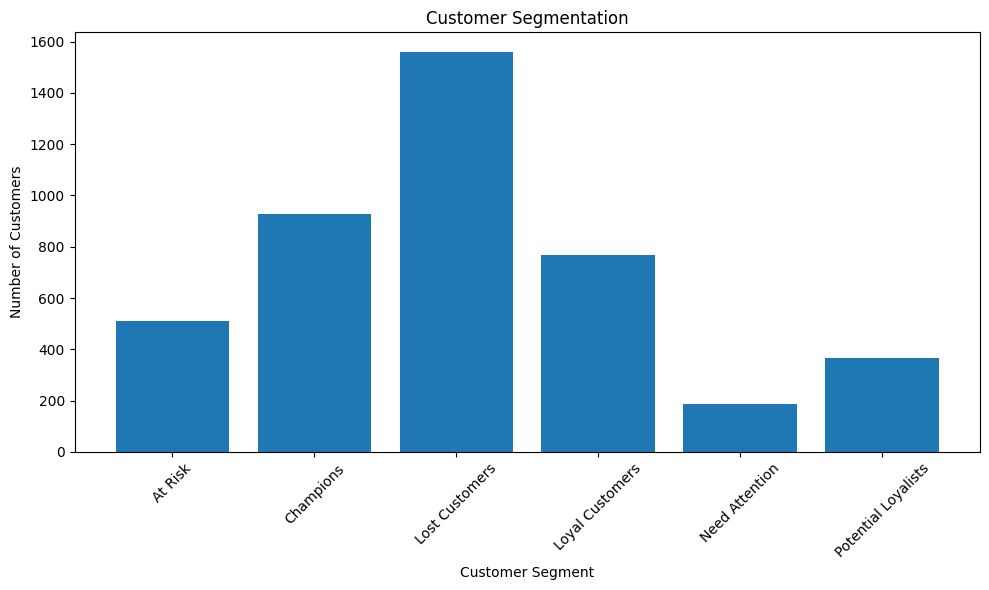

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Customers"]
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [46]:
rfm.to_csv("Final_RFM_Segmentation.csv", index=False)

print("Final RFM Segmentation file saved.")

Final RFM Segmentation file saved.


In [47]:
recommendations = {
    "Champions": "Reward loyal customers with exclusive offers, early access, and loyalty benefits.",

    "Loyal Customers": "Encourage repeat purchases with loyalty rewards, personalized offers, and cross-selling.",

    "Potential Loyalists": "Use targeted promotions and product recommendations to encourage more frequent purchases.",

    "At Risk": "Run re-engagement campaigns with personalized discounts and reminders.",

    "Need Attention": "Send targeted offers and product suggestions to encourage another purchase.",

    "Lost Customers": "Use win-back campaigns with attractive offers and personalized communication."
}

for segment, recommendation in recommendations.items():
    print(f"{segment}: {recommendation}")

Champions: Reward loyal customers with exclusive offers, early access, and loyalty benefits.
Loyal Customers: Encourage repeat purchases with loyalty rewards, personalized offers, and cross-selling.
Potential Loyalists: Use targeted promotions and product recommendations to encourage more frequent purchases.
At Risk: Run re-engagement campaigns with personalized discounts and reminders.
Need Attention: Send targeted offers and product suggestions to encourage another purchase.
Lost Customers: Use win-back campaigns with attractive offers and personalized communication.


In [48]:
recommendation_table = pd.DataFrame(
    list(recommendations.items()),
    columns=["Segment", "Recommendation"]
)

recommendation_table

,Segment,Recommendation
0,Champions,"Reward loyal customers with exclusive offers, ..."
1,Loyal Customers,Encourage repeat purchases with loyalty reward...
2,Potential Loyalists,Use targeted promotions and product recommenda...
3,At Risk,Run re-engagement campaigns with personalized ...
4,Need Attention,Send targeted offers and product suggestions t...
5,Lost Customers,Use win-back campaigns with attractive offers ...


In [49]:
rfm.to_csv("Final_RFM_Segmentation.csv", index=False)

segment_summary.to_csv("Segment_Summary.csv", index=False)

recommendation_table.to_csv("Recommendations.csv", index=False)

print("All Task 12 files saved successfully.")

All Task 12 files saved successfully.
